In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression


In [2]:
np.random.seed(42)

df = pd.DataFrame({
    "Age": np.random.randint(18, 30, 100),
    "Study_Hours": np.random.randint(1, 8, 100),
    "Attendance": np.random.randint(60, 100, 100),
    "Marks": np.random.randint(40, 100, 100),
    "Pass": np.random.choice([0, 1], 100)
})

df.head()

,Age,Study_Hours,Attendance,Marks,Pass
0,24,1,86,74,1
1,21,7,72,64,1
2,28,1,62,68,1
3,25,1,98,57,0
4,22,4,65,85,1


In [3]:
X = df[["Age", "Study_Hours", "Attendance", "Marks"]]
y = df["Pass"]

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)

Training Data Shape: (80, 4)
Testing Data Shape: (20, 4)


In [5]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed.")

Feature scaling completed.


In [6]:
model = LogisticRegression()

model.fit(X_train_scaled, y_train)

print("Model trained successfully.")

Model trained successfully.


In [7]:
accuracy = model.score(X_test_scaled, y_test)

print("Test Accuracy:", round(accuracy * 100, 2), "%")

Test Accuracy: 60.0 %


In [8]:
scores = cross_val_score(
    model,
    scaler.fit_transform(X),
    y,
    cv=5
)

print("Cross Validation Scores:")
print(scores)

print("Average Accuracy:", scores.mean())

Cross Validation Scores:
[0.6 0.6 0.5 0.5 0.5]
Average Accuracy: 0.54


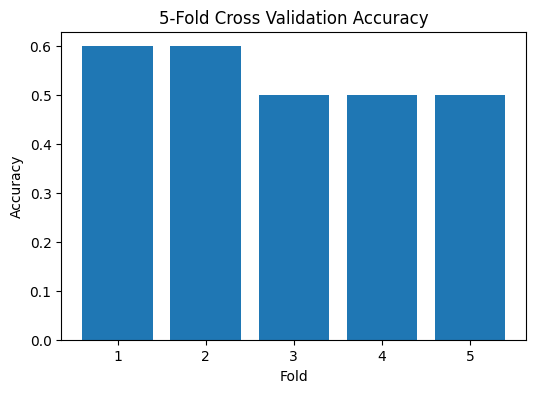

In [9]:
plt.figure(figsize=(6,4))

plt.bar(
    range(1,6),
    scores
)

plt.title("5-Fold Cross Validation Accuracy")
plt.xlabel("Fold")
plt.ylabel("Accuracy")

plt.show()

In [10]:
df.to_csv("train_test_dataset.csv", index=False)

print("Dataset saved successfully.")

Dataset saved successfully.
